In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder 

In [5]:
df = pd.read_csv(r"c:\Users\BM\Downloads\archive.zip")

In [6]:
df.shape

(10000, 8)

In [6]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [7]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [7]:
df.tail(6)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9994,TXN_7851634,UNKNOWN,4,4.0,16.0,NaN,NaN,2023-01-08
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3,4.0,12.0,Cash,In-store,2023-11-07


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [9]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

<Axes: >

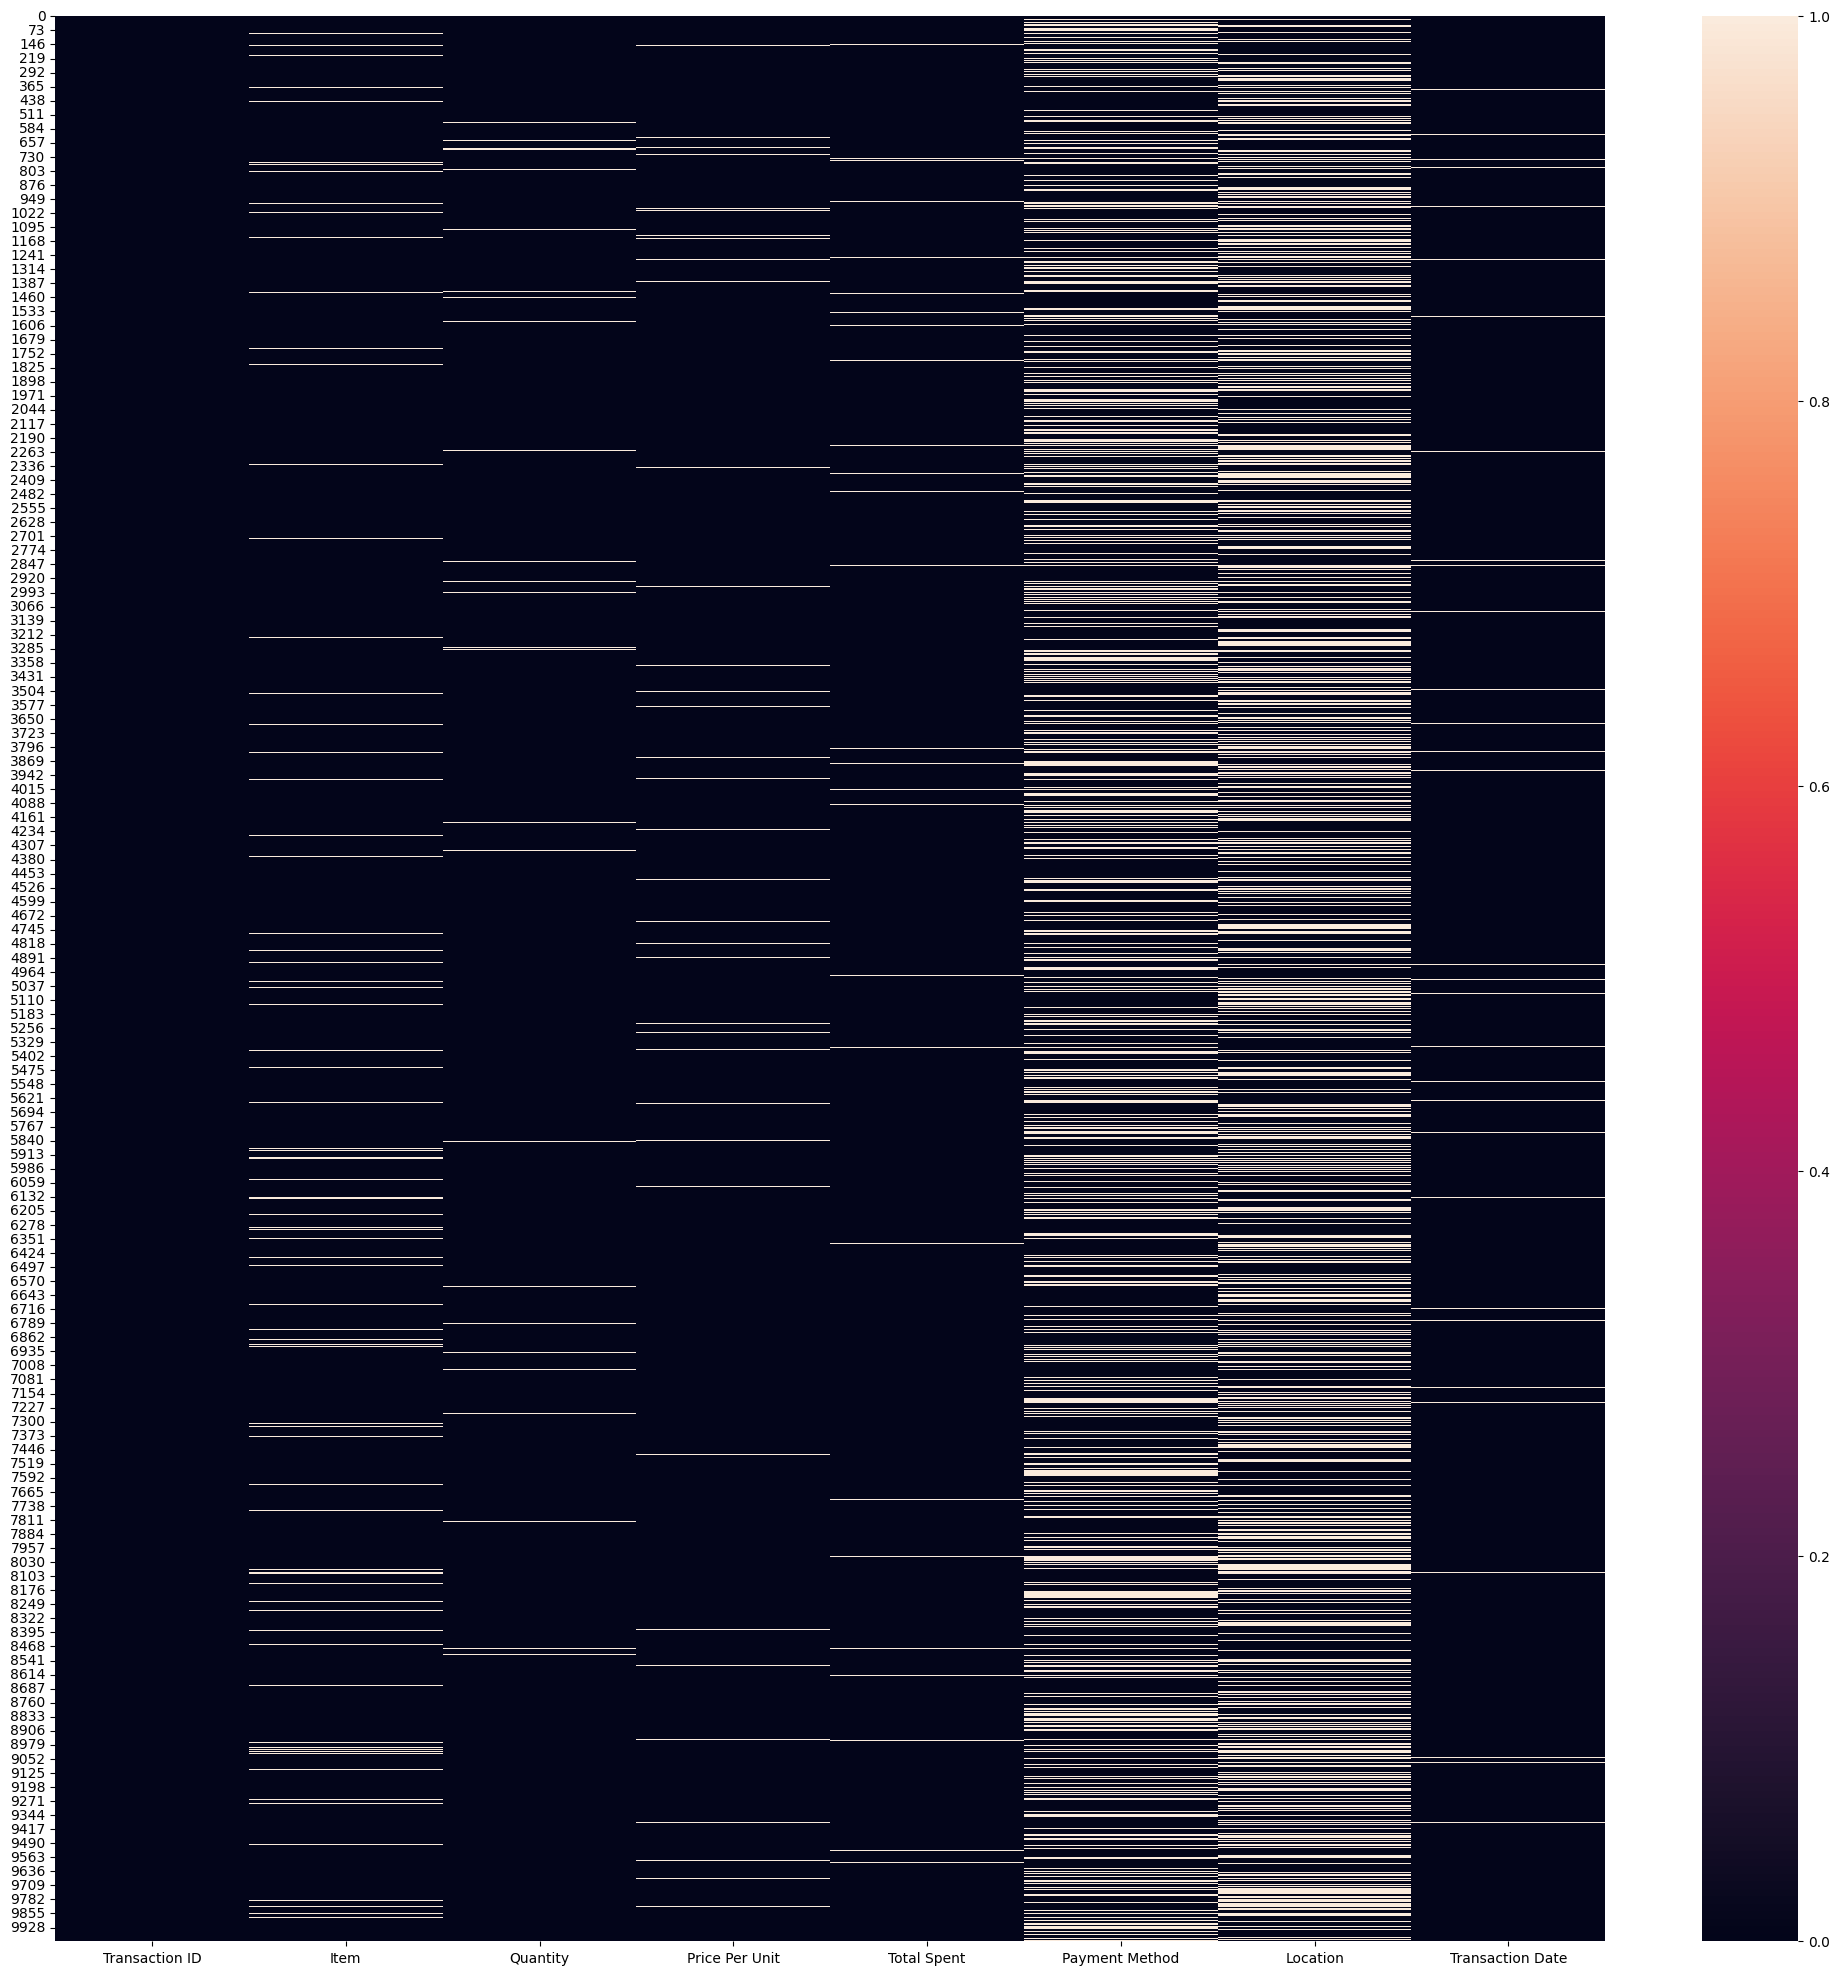

In [50]:
plt.figure(figsize=(25,25)) 
sns.heatmap(df.isnull())

In [51]:
null_var=df.isnull().sum()/df.shape[0]*100 
null_var

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [52]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [53]:
num_cols = ['Quantity','Price Per Unit','Total Spent']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ['Item','Payment Method','Location']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [55]:
df['Transaction Date'] = df['Transaction Date'].fillna(df['Transaction Date'].mode()[0])

In [56]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

<Axes: >

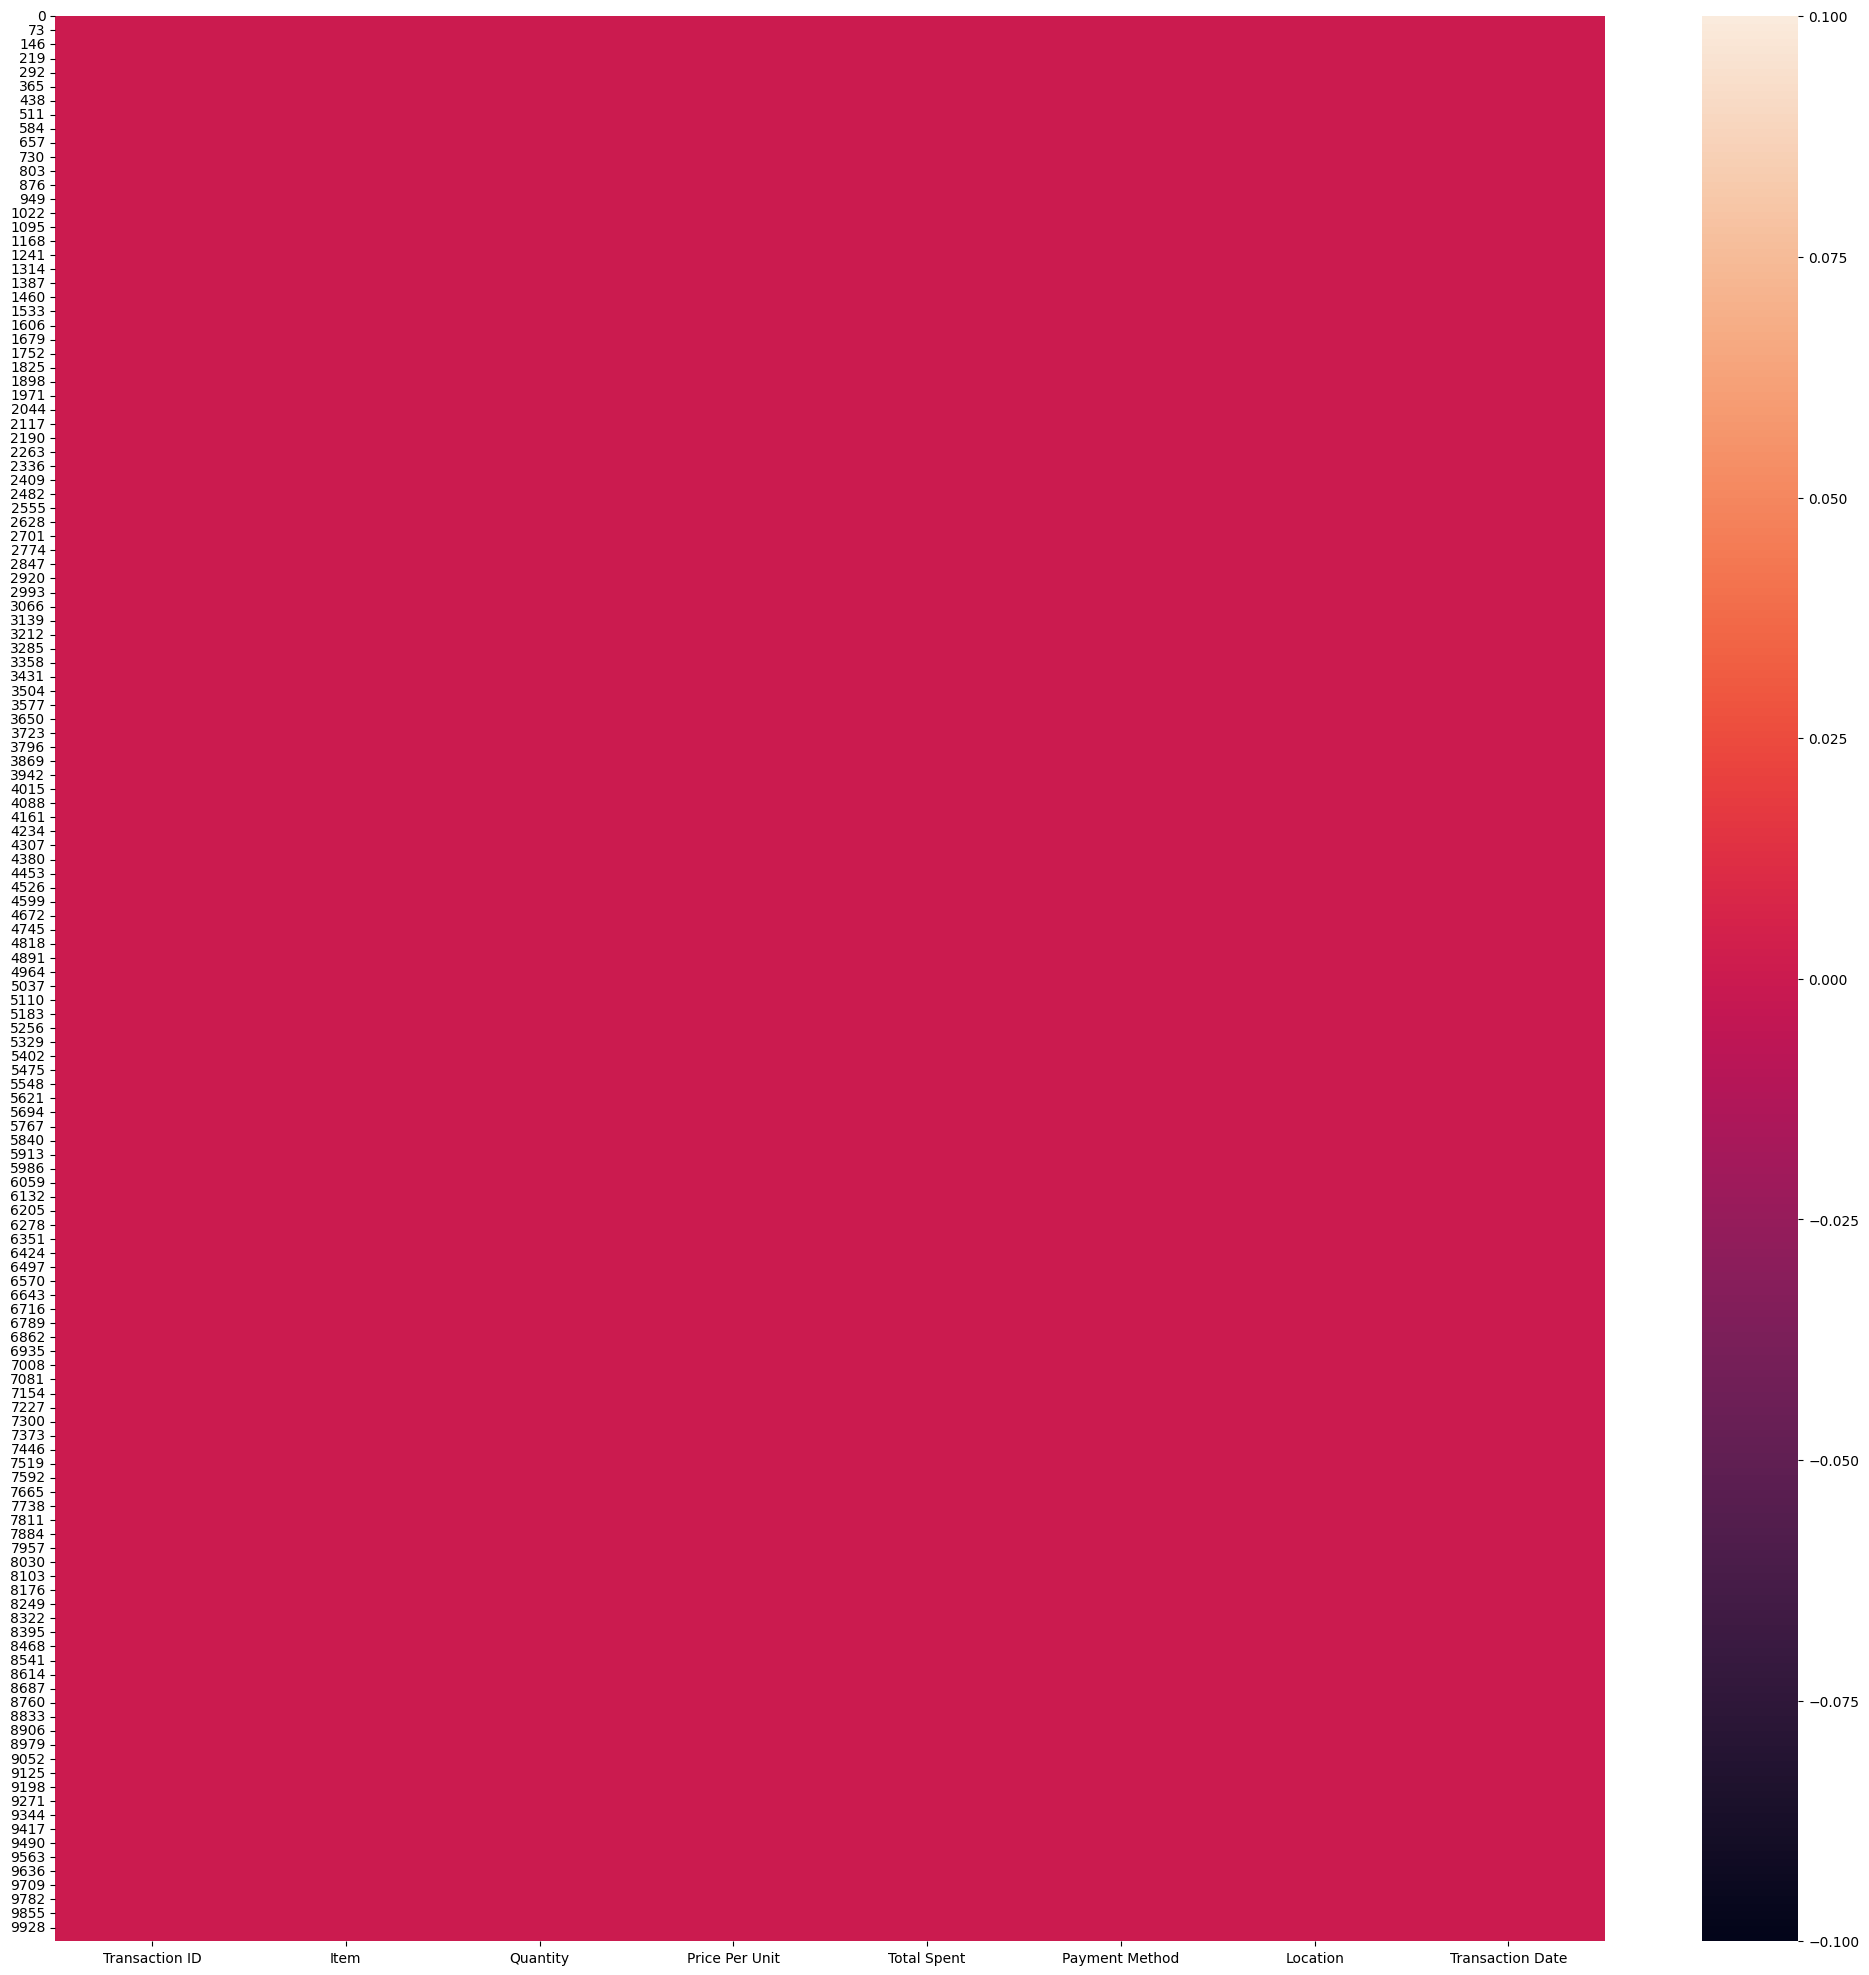

In [57]:
plt.figure(figsize=(25,25)) 
sns.heatmap(df.isnull()) 

In [58]:
df.select_dtypes(include=['int64','float64']).columns 

Index(['Quantity', 'Price Per Unit', 'Total Spent'], dtype='str')

In [59]:
df.select_dtypes(include=['object','str']).columns

Index(['Transaction ID', 'Item', 'Payment Method', 'Location',
       'Transaction Date'],
      dtype='str')

In [60]:
df['Transaction ID'].value_counts()

Transaction ID
TXN_1961373    1
TXN_4977031    1
TXN_4271903    1
TXN_7034554    1
TXN_3160411    1
TXN_2602893    1
TXN_4433211    1
TXN_6699534    1
TXN_4717867    1
TXN_2064365    1
TXN_2548360    1
TXN_3051279    1
TXN_7619095    1
TXN_9437049    1
TXN_8915701    1
TXN_2847255    1
TXN_3765707    1
TXN_6769710    1
TXN_8876618    1
TXN_3709394    1
TXN_3522028    1
TXN_3567645    1
TXN_5132361    1
TXN_2616390    1
TXN_9400181    1
TXN_7958992    1
TXN_5183041    1
TXN_5695074    1
TXN_8467949    1
TXN_7640952    1
TXN_1736287    1
TXN_8927252    1
TXN_9677376    1
TXN_7710508    1
TXN_8853997    1
TXN_9130559    1
TXN_6855453    1
TXN_1080432    1
TXN_2655815    1
TXN_6688524    1
TXN_2083138    1
TXN_2427584    1
TXN_6650263    1
TXN_9620080    1
TXN_1491578    1
TXN_5455792    1
TXN_8078640    1
TXN_9499313    1
TXN_8201146    1
TXN_8230936    1
TXN_7742742    1
TXN_6342161    1
TXN_8914892    1
TXN_3363746    1
TXN_8614868    1
TXN_5522862    1
TXN_3578141    1
TXN_2080895    1

In [61]:
df['Transaction ID'].value_counts()/df.shape[0]*100

Transaction ID
TXN_1961373    0.01
TXN_4977031    0.01
TXN_4271903    0.01
TXN_7034554    0.01
TXN_3160411    0.01
TXN_2602893    0.01
TXN_4433211    0.01
TXN_6699534    0.01
TXN_4717867    0.01
TXN_2064365    0.01
TXN_2548360    0.01
TXN_3051279    0.01
TXN_7619095    0.01
TXN_9437049    0.01
TXN_8915701    0.01
TXN_2847255    0.01
TXN_3765707    0.01
TXN_6769710    0.01
TXN_8876618    0.01
TXN_3709394    0.01
TXN_3522028    0.01
TXN_3567645    0.01
TXN_5132361    0.01
TXN_2616390    0.01
TXN_9400181    0.01
TXN_7958992    0.01
TXN_5183041    0.01
TXN_5695074    0.01
TXN_8467949    0.01
TXN_7640952    0.01
TXN_1736287    0.01
TXN_8927252    0.01
TXN_9677376    0.01
TXN_7710508    0.01
TXN_8853997    0.01
TXN_9130559    0.01
TXN_6855453    0.01
TXN_1080432    0.01
TXN_2655815    0.01
TXN_6688524    0.01
TXN_2083138    0.01
TXN_2427584    0.01
TXN_6650263    0.01
TXN_9620080    0.01
TXN_1491578    0.01
TXN_5455792    0.01
TXN_8078640    0.01
TXN_9499313    0.01
TXN_8201146    0.01
TXN_8

In [62]:
df['Transaction ID'].value_counts().shape[0]*1
00

0

In [10]:
pd.concat([df['Transaction ID'].value_counts()/df.shape[0]*100,           
df['Transaction ID'].value_counts()/df.shape[0]*100],
axis=1, keys=['Transaction ID_org','Transaction ID_clean']) 

,Transaction ID_org,Transaction ID_clean
Transaction ID,,
TXN_1961373,0.01,0.01
TXN_4977031,0.01,0.01
TXN_4271903,0.01,0.01
TXN_7034554,0.01,0.01
TXN_3160411,0.01,0.01
...,...,...
TXN_7672686,0.01,0.01
TXN_9659401,0.01,0.01
TXN_5255387,0.01,0.01


In [11]:
dummy_df=pd.get_dummies(df) 
dummy_df 

,Transaction ID_TXN_1000555,Transaction ID_TXN_1001832,Transaction ID_TXN_1002457,Transaction ID_TXN_1003246,Transaction ID_TXN_1004184,Transaction ID_TXN_1004563,Transaction ID_TXN_1005331,Transaction ID_TXN_1005377,Transaction ID_TXN_1005472,Transaction ID_TXN_1006942,...,Transaction Date_2023-12-24,Transaction Date_2023-12-25,Transaction Date_2023-12-26,Transaction Date_2023-12-27,Transaction Date_2023-12-28,Transaction Date_2023-12-29,Transaction Date_2023-12-30,Transaction Date_2023-12-31,Transaction Date_ERROR,Transaction Date_UNKNOWN
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
pd.get_dummies(df,drop_first=True)

,Transaction ID_TXN_1001832,Transaction ID_TXN_1002457,Transaction ID_TXN_1003246,Transaction ID_TXN_1004184,Transaction ID_TXN_1004563,Transaction ID_TXN_1005331,Transaction ID_TXN_1005377,Transaction ID_TXN_1005472,Transaction ID_TXN_1006942,Transaction ID_TXN_1007347,...,Transaction Date_2023-12-24,Transaction Date_2023-12-25,Transaction Date_2023-12-26,Transaction Date_2023-12-27,Transaction Date_2023-12-28,Transaction Date_2023-12-29,Transaction Date_2023-12-30,Transaction Date_2023-12-31,Transaction Date_ERROR,Transaction Date_UNKNOWN
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
oh_enco = OneHotEncoder(sparse_output=False)

In [14]:
oh_enco_arr=oh_enco.fit_transform(df[[]])

In [15]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [16]:
 
oh_enco_arr=oh_enco.fit_transform(df[['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent','Payment Method', 'Location', 'Transaction Date']])

In [17]:
oh_enco_arr

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 10427))

In [18]:
dummy_df.keys() 

Index(['Transaction ID_TXN_1000555', 'Transaction ID_TXN_1001832',
       'Transaction ID_TXN_1002457', 'Transaction ID_TXN_1003246',
       'Transaction ID_TXN_1004184', 'Transaction ID_TXN_1004563',
       'Transaction ID_TXN_1005331', 'Transaction ID_TXN_1005377',
       'Transaction ID_TXN_1005472', 'Transaction ID_TXN_1006942',
       ...
       'Transaction Date_2023-12-24', 'Transaction Date_2023-12-25',
       'Transaction Date_2023-12-26', 'Transaction Date_2023-12-27',
       'Transaction Date_2023-12-28', 'Transaction Date_2023-12-29',
       'Transaction Date_2023-12-30', 'Transaction Date_2023-12-31',
       'Transaction Date_ERROR', 'Transaction Date_UNKNOWN'],
      dtype='str', length=10420)

In [20]:
oh_enco_df = pd.DataFrame(
    oh_enco_arr,
    columns=oh_enco.get_feature_names_out()
)